<a href="https://colab.research.google.com/github/ayanrasulova/rent-estimations-cv/blob/main/tabular_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

DRIVE_DIR = '/content/drive/MyDrive/cv_project'

Mounted at /content/drive


In [2]:

# load
df = pd.read_csv(os.path.join(DRIVE_DIR, 'listings_clean.csv'))
print(f"Loaded: {len(df)} rows")

# clean
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['sqft']  = pd.to_numeric(df['sqft'].astype(str).str.replace(',', '').str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

for col in ['beds', 'baths', 'year_built', 'walk_score', 'bike_score', 'parking_total_spaces']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['price', 'beds', 'sqft'])

q_low  = df['price'].quantile(0.01)
q_high = df['price'].quantile(0.99)
df = df[(df['price'] >= q_low) & (df['price'] <= q_high)]
print(f"After cleaning: {len(df)} rows")
print(f"Price range: ${df['price'].min():,.0f} – ${df['price'].max():,.0f}")

Loaded: 8400 rows
After cleaning: 8240 rows
Price range: $189,900 – $7,495,000


In [3]:

# features
TABULAR = ['beds', 'baths', 'sqft', 'year_built', 'walk_score',
           'bike_score', 'parking_total_spaces']

df = pd.get_dummies(df, columns=['property_type', 'region'], drop_first=True)
ohe_cols = [c for c in df.columns if c.startswith('property_type_') or c.startswith('region_')]
TABULAR  = TABULAR + ohe_cols

bool_cols = [c for c in df.columns if df[c].dtype == bool]
df[bool_cols] = df[bool_cols].astype(int)

X = df[TABULAR].apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median(numeric_only=True)).values
y = df['price'].values

In [4]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

In [5]:
# train models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

print(f"\n{'Model':20s} | {'MAE':>12} | {'RMSE':>12} | {'R²':>6}")
print("-" * 60)
results = {}
for name, m in models.items():
    X_tr = X_train_sc if name == 'Linear Regression' else X_train
    X_te = X_test_sc  if name == 'Linear Regression' else X_test
    m.fit(X_tr, y_tr := y_train)
    preds = m.predict(X_te)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'preds': preds}
    print(f"{name:20s} | ${mae:>10,.0f} | ${rmse:>10,.0f} | {r2:.3f}")


Model                |          MAE |         RMSE |     R²
------------------------------------------------------------
Linear Regression    | $   383,566 | $   637,616 | 0.644
Decision Tree        | $   375,766 | $   655,141 | 0.624
Random Forest        | $   303,930 | $   564,401 | 0.721


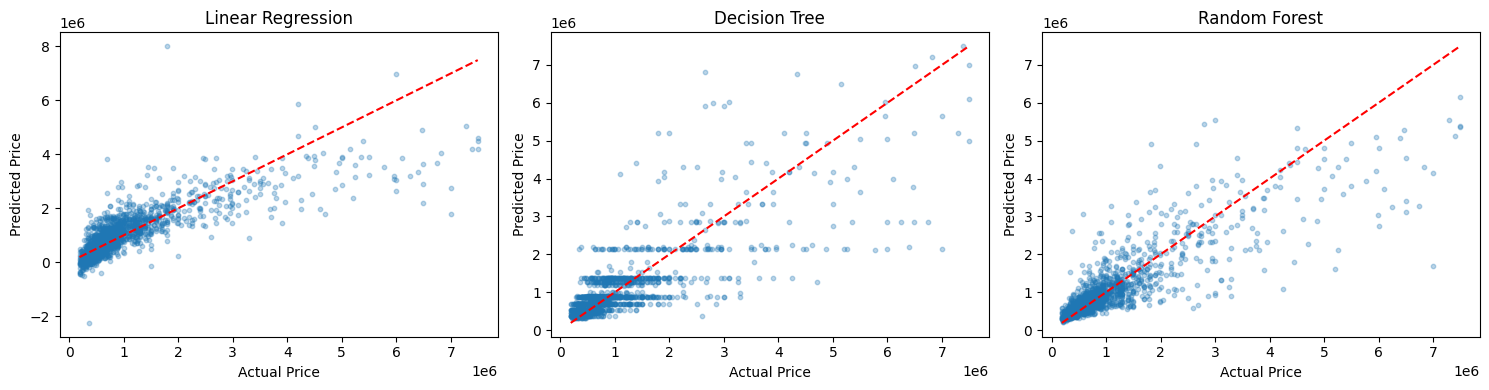

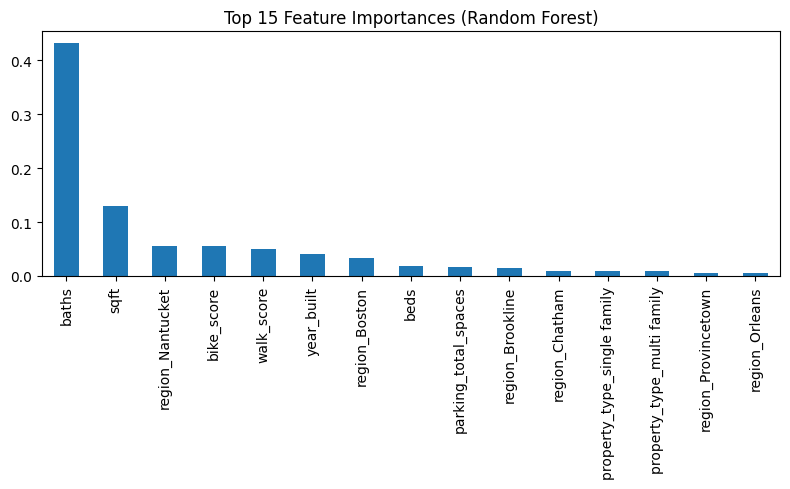

In [6]:
# plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    ax.scatter(y_test, res['preds'], alpha=0.3, s=10)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(name)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'baseline_predictions.png'))
plt.show()

rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=TABULAR).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
importances.plot(kind='bar')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'feature_importance.png'))
plt.show()